In [1]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from lib.data_loader import *
from lib.U2_gate import *
from lib.U3_gate import *
from lib.U4_gate import *
from lib.train_test import *

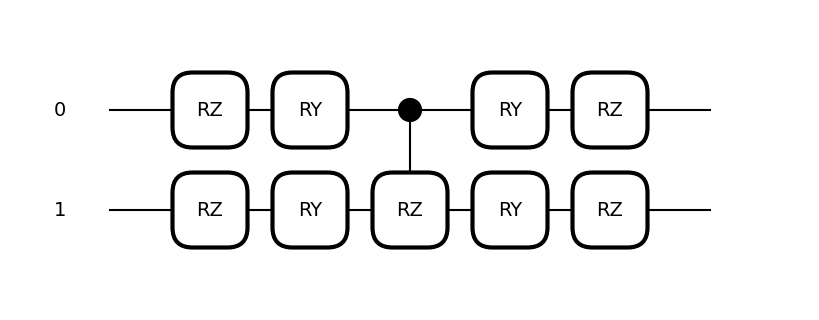

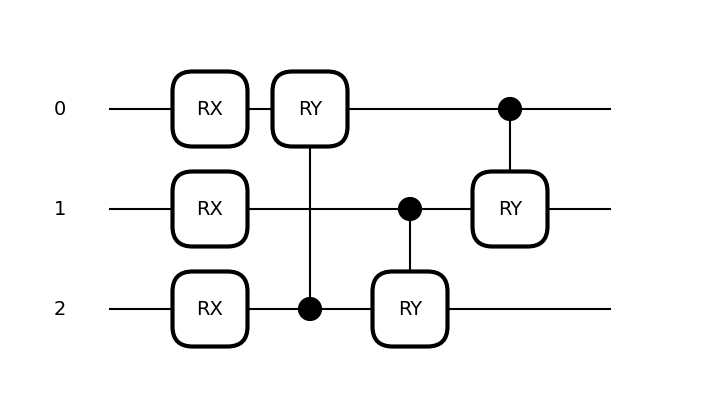

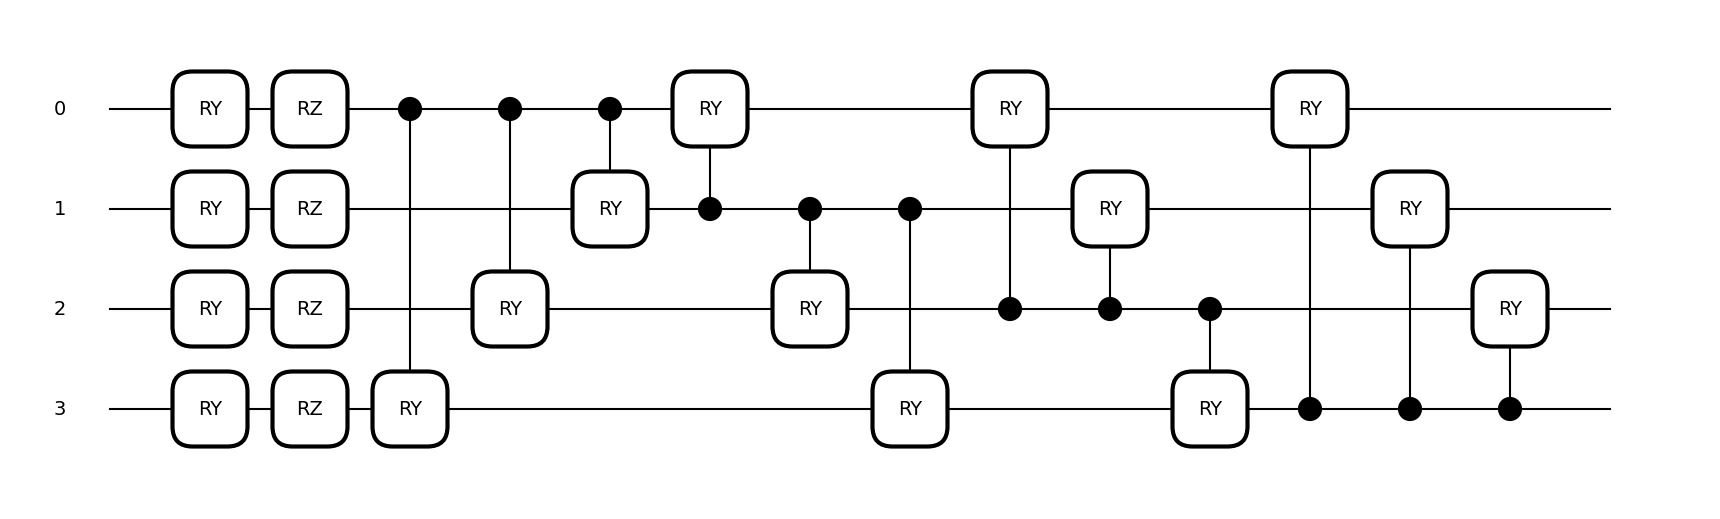

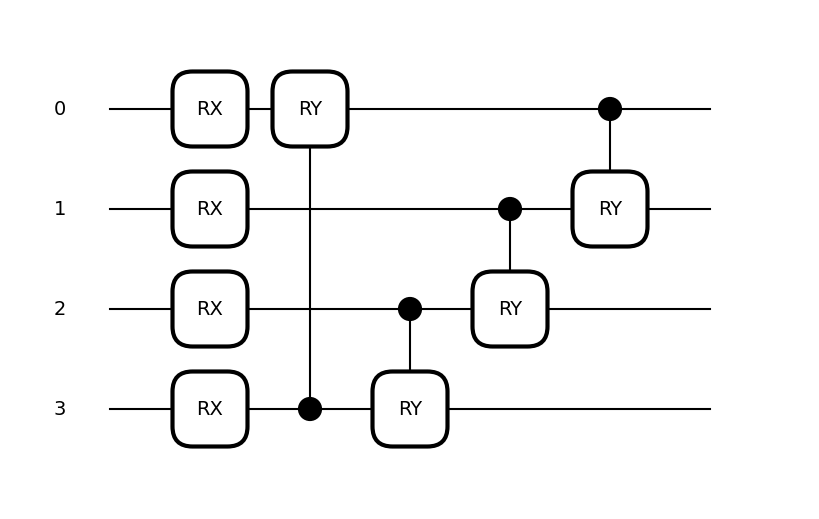

In [ ]:
n_wires = 10
n_layers = 1
dev = qml.device('default.qubit', wires=n_wires)

U2_1 = u2_1()
U2_2 = u2_2()
U3_CB_1 = u3_cb_1()
U3_CB_2 = u3_cb_2()
U3_AA_1 = u3_aa_1()
U4_AA_1 = u4_aa_1()
U4_CB_1 = u4_cb_1()
U4_CB_2 = u4_cb_2()
U4_NN_1 = u4_nn_1()
U4_NN_2 = u4_nn_2()

gate_list = [U2_2, U3_CB_2, U4_AA_1, U4_CB_2]

for gate in gate_list:
    fig, ax = qml.draw_mpl(gate.circuit)(weights=np.random.randn(gate.weight_size), wires=range(gate.gate_size))

In [ ]:
# define a QuantumLayer with NN structure 
def createLayers(gate, start_wire):
    def layer(weights, wires):
        active_wires = wires[start_wire:]
        num_active = len(active_wires)
        for i in range(num_active):
            tmp_wires = [active_wires[(i + j) % num_active] for j in range(gate.gate_size)]
            gate.circuit(weights=weights[i], wires=tmp_wires)
    return layer

def create_circuit(dev, layers, n_wires):
    """define a quantum circuit with n_wires qubits and layers

    dev --- device
    layers --- list of quantum conv kernel layer
    n_wires --- number of qubits 
    """
    @qml.qnode(dev)
    def circuit(inputs, weights_0, weights_1, weights_2, weights_3, weights_4):
        '''define a quantum circuit with Amplitude Embedding & controlled quibits & conv layers

        inputs --- input data
        weights --- parameter of quantum circuit
        '''
        ctrl_wires = [0, 1]
        target_wires = list(range(2, n_wires))
        
        qml.AmplitudeEmbedding(inputs, wires=range(n_wires), pad_with=0.)
        qml.ctrl(layers[0], control=ctrl_wires)(weights_0, wires=target_wires)
        qml.X(wires=1)
        qml.ctrl(layers[1], control=ctrl_wires)(weights_1, wires=target_wires)
        qml.X(wires=0)
        qml.ctrl(layers[3], control=ctrl_wires)(weights_3, wires=target_wires)
        qml.X(wires=1)
        qml.ctrl(layers[2], control=ctrl_wires)(weights_2, wires=target_wires)
        qml.X(wires=0)

        qml.Hadamard(wires=0)
        qml.Hadamard(wires=1)

        for i in range(0, len(weights_4)):
            qml.CRY(weights_4[i],wires=[2*(i+1), 2*(i+1)+1])

        return qml.probs(wires=[3, 5, 7, 9])
    
    return circuit


In [ ]:
layer_list = [createLayers(gate, 2) for gate in gate_list]
circuit = create_circuit(dev, layer_list, n_wires)

np.random.seed(42)

weight_shapes = {
    "weights_0": (n_wires - 2, gate_list[0].weight_size),
    "weights_1": (n_wires - 2, gate_list[1].weight_size),
    "weights_2": (n_wires - 2, gate_list[2].weight_size),
    "weights_3": (n_wires - 2, gate_list[3].weight_size),
    "weights_4": (4,),
    }
qlayer = qml.qnn.TorchLayer(circuit, weight_shapes)

In [ ]:
class QCNNModel(nn.Module):
    def __init__(self, qlayer):
        super().__init__()
        self.flatten = nn.Flatten()
        self.conv = nn.Conv2d(in_channels=4, out_channels=4, kernel_size=2, stride=2, padding=2)  # 16*16
        self.relu = nn.ReLU()
        self.qlayer = qlayer
        self.fc2 = nn.Linear(16, 4)
    
    def forward(self, x):
        x = self.conv(x) 
        # print(x.shape)
        x = self.flatten(x) 
        # print(x.shape)
        x = qlayer(x)     
        # print(x.shape)
        x = self.relu(x) 
        x = self.fc2(x)  
        return x

Shape of X [N, C, H, W]:+--------------------------------------------------------------- torch.Size([25, 1, 28, 28])
Shape of y: torch.Size([25]) torch.int64
train_images's shape is :  torch.Size([25, 1, 28, 28])
train_labels's shape is :  torch.Size([25])
Training Samples:


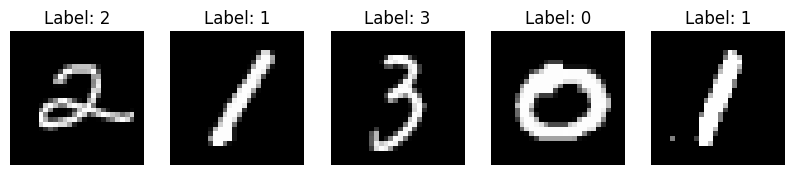

Testing Samples:


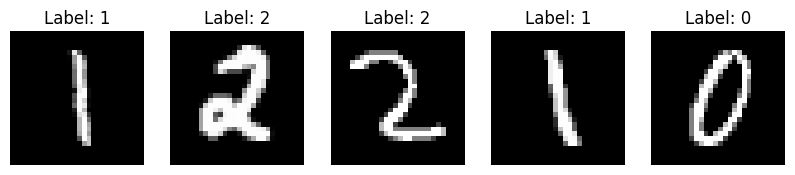

In [ ]:
# MNIST
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root="../data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="../data", train=False, download=True, transform=transform)
train_loader, test_loader = getDataloader(train_dataset, test_dataset, range(4), train_size=5000, test_size=1000, batch_size=25, shuffle=True)


In [ ]:
epochs = 50

print("qlayer\n-------------------------------\n-------------------------------")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = QCNNModel(qlayer).to(device)
print(model)
loss_fn = nn.CrossEntropyLoss()
learning_rate = 0.01
optimizer = optim.Adam(model.parameters(), lr = learning_rate)
acc_list = []
loss_list = []
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_multi_channel(train_loader, model, loss_fn, 25, optimizer, device)
    acc, loss = test_multi_channel_all(test_loader, model, loss_fn, device)
    acc_list.append(acc)
    loss_list.append(loss)
print("Done!")

qlayer
-------------------------------
-------------------------------
QCNNModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (conv): Conv2d(4, 4, kernel_size=(2, 2), stride=(2, 2), padding=(2, 2))
  (relu): ReLU()
  (qlayer): <Quantum Torch Layer: func=circuit>
  (fc2): Linear(in_features=16, out_features=4, bias=True)
)
Epoch 1
-------------------------------
loss: 1.374450  [   25/20000]
loss: 1.354223  [  650/20000]
loss: 1.327928  [ 1275/20000]
loss: 1.236927  [ 1900/20000]
loss: 1.129227  [ 2525/20000]
loss: 1.179687  [ 3150/20000]
loss: 1.076342  [ 3775/20000]
loss: 0.937370  [ 4400/20000]
loss: 0.940247  [ 5025/20000]
loss: 0.806350  [ 5650/20000]
loss: 0.755797  [ 6275/20000]
loss: 0.679000  [ 6900/20000]
loss: 0.838451  [ 7525/20000]
loss: 0.797385  [ 8150/20000]
loss: 0.829890  [ 8775/20000]
loss: 0.737372  [ 9400/20000]
loss: 0.568088  [10025/20000]
loss: 0.703059  [10650/20000]
loss: 0.672846  [11275/20000]
loss: 0.491454  [11900/20000]
loss: 0.571911  [12525/20000]
lo

In [11]:
print(acc_list)
print(loss_list)

[0.907537688442211, 0.9180904522613065, 0.9309045226130653, 0.9414572864321608, 0.9474874371859296, 0.9545226130653266, 0.9605527638190955, 0.963819095477387, 0.9688442211055276, 0.9703517587939698, 0.9721105527638191, 0.9726130653266332, 0.9728643216080402, 0.9693467336683417, 0.9751256281407035, 0.9751256281407035, 0.9748743718592965, 0.9776381909547739, 0.9796482412060301, 0.9806532663316583, 0.9766331658291457, 0.9821608040201005, 0.9809045226130654, 0.9831658291457287, 0.9826633165829146, 0.9824120603015075, 0.9819095477386934, 0.9826633165829146, 0.9846733668341708, 0.9836683417085427, 0.9849246231155779, 0.9851758793969849, 0.9846733668341708, 0.9846733668341708, 0.9841708542713568, 0.9851758793969849, 0.9851758793969849, 0.9844221105527639, 0.9834170854271357, 0.9839195979899498, 0.9839195979899498, 0.9851758793969849, 0.9844221105527639, 0.9826633165829146, 0.9871859296482413, 0.9841708542713568, 0.9851758793969849, 0.9854271356783919, 0.9869346733668342, 0.9854271356783919]
[